## Imports and Basic Function and Read Dataframe Temperature

In [1]:
import sys, os
import numpy as np
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
import pandas as pd
import matplotlib.pyplot as plt
import  jdatetime

In [2]:
def jalali_to_gregorian_fast(date_str):
    jy, jm, jd = map(int, date_str.split('/'))
    jdate = jdatetime.date(jy, jm, jd)
    gdate = jdate.togregorian()
    return f"{gdate.year}-{gdate.month:02d}-{gdate.day:02d}"

In [3]:
csv_semi_processed_path = os.path.join(project_root, "data", "raw", "PlantsTemperature_View_original.csv")
df_c = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [4]:
df = df_c.sort_values(by=['Date','HourNo'])
df["HourNo"] = df["HourNo"].astype(int)
df["Date"] = df["Date"].apply(jalali_to_gregorian_fast)
df["datetime"] = pd.to_datetime(df["Date"]) + pd.to_timedelta(df["HourNo"],unit='h')

is_env = df["Code"] == "SCADAF"
df_sen = df[~is_env]
df_env = df[is_env]
len(df_sen),len(df_env)

(336052, 426814)

## show Temperature over Time

In [5]:
import matplotlib.pyplot as plt
def show_date(dates):
    dates = dates.copy()
    full_range = pd.date_range(start=dates.min(), end=dates.max(), freq='h')
    df = pd.DataFrame({'datetime': full_range})
    df['Value'] = 0
    df.loc[df['datetime'].isin(dates), 'Value'] = 1
    plt.figure(figsize=(12, 6))
    plt.plot(df['datetime'], df['Value'], drawstyle='steps-post', marker='.')
    plt.xlabel('Date and Time')
    plt.ylabel('Value')
    plt.title('Date and Time Presence')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
    return df[df['Value'] == 0]["datetime"]

def show_temperature(df,flag=False):
    a, _ = np.unique(df['datetime'].to_numpy(), return_counts=True)
    datestimes = show_date(a)
    datess = datestimes.dt.date
    print(len(datestimes),len(datess.unique()))
    for d in datess.unique():
        t = datestimes[datess == d].dt.hour.to_list()
        if flag :
            print(d,len(t),t)

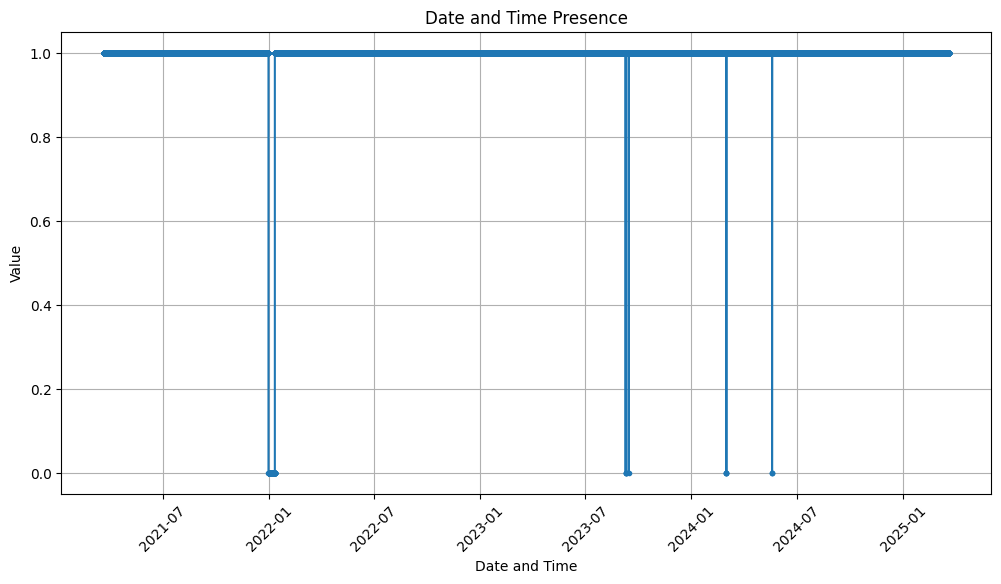

278 16


In [6]:
show_temperature(df[df['PowerPlantName']=="پرند"])
#show_temperature(df_env[df_env['PowerPlantName']=="پرند"])
#show_temperature(df_sen[df_sen['PowerPlantName']=="پرند"])

## Generation over Temperature

In [7]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_s = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
df_s['date'] = pd.to_datetime(df_s['date'])
df_s['datetime'] = df_s['date'] + pd.to_timedelta(df_s['hour'], unit='h')

In [11]:
df_sen["PowerPlantName"].unique()

array(['پرند', 'شهدای پاکدشت - دماوند', 'قم', 'گیلان',
       'شهدای پیروز - بهبهان', 'جنوب اصفهان - چهلستون', 'شهید منتظری 1',
       'سبلان', 'سیکل ترکیبی ارومیه', 'سیکل ترکیبی یزد', 'عسلویه', 'حافظ',
       'سیکل ترکیبی شیروان'], dtype=object)

In [30]:
import plotly.express as px
import plotly.graph_objects as go

power_plants = df_s[['name', 'code']].drop_duplicates()
for _, row in power_plants.iterrows():
    name, code = row['name'], row['code']

    # فیلتر کردن داده‌ها
    df_s2 = df_s[(df_s['name'] == name) & (df_s['code'] == code) & (df_s["is_good_peak"] >= 3)]
    df_sen2 = df_sen[df_sen['PowerPlantName'] == name]
    df_merged = pd.merge(df_s2, df_sen2, on="datetime", how="inner")
    #print(len(df_merged), len(df_s2))

    # انتخاب ستون‌های مورد نیاز و حذف مقادیر NaN
    my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
    gens = my_cols['generation'].values
    temp_senses = my_cols['Value'].values
    my_cols['date'] = pd.to_datetime(my_cols['date'])
    my_cols['year'] = my_cols['date'].dt.year

    # ایجاد نمودار پراکندگی
    fig = go.Figure()

    fig = px.scatter(
    my_cols,
    x='Value',
    y='generation',
    color='year',
    title=f'نمودار پراکندگی دمای حس شده vs تولید - {name+"-"+code}',
    labels={'Value': 'دمای توربین', 'generation': 'تولید (مگاوات)', 'year': 'سال'},
    hover_data=['date', 'hour', 'temperature'],
    category_orders={'year': ['2021', '2022', '2023', '2024', '2025']}  # ترتیب سال‌ها
    )

    fig.update_traces(marker=dict(size=5, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))

    fig.update_layout(
        font_family='Tahoma',
        title_font_size=16
    )

    fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature_color/{name}-{code}.html")

In [31]:
import plotly.express as px
import plotly.graph_objects as go

power_plants = df_s[['name', 'code']].drop_duplicates()
for _, row in power_plants.iterrows():
    name, code = row['name'], row['code']

    # فیلتر کردن داده‌ها
    df_s2 = df_s[(df_s['name'] == name) & (df_s['code'] == code) & (df_s["is_good_peak"] >= 0)]
    df_sen2 = df_sen[df_sen['PowerPlantName'] == name]
    df_merged = pd.merge(df_s2, df_sen2, on="datetime", how="inner")
    #print(len(df_merged), len(df_s2))

    # انتخاب ستون‌های مورد نیاز و حذف مقادیر NaN
    my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
    gens = my_cols['generation'].values
    temp_senses = my_cols['Value'].values
    my_cols['date'] = pd.to_datetime(my_cols['date'])
    my_cols['year'] = my_cols['date'].dt.year

    # ایجاد نمودار پراکندگی
    fig = go.Figure()

    fig = px.scatter(
    my_cols,
    x='Value',
    y='generation',
    color='year',
    title=f'نمودار پراکندگی دمای حس شده vs تولید - {name+"-"+code}',
    labels={'Value': 'دمای توربین', 'generation': 'تولید (مگاوات)', 'year': 'سال'},
    hover_data=['date', 'hour', 'temperature'],
    category_orders={'year': ['2021', '2022', '2023', '2024', '2025']}  # ترتیب سال‌ها
    )

    fig.update_traces(marker=dict(size=5, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))

    fig.update_layout(
        font_family='Tahoma',
        title_font_size=16
    )

    fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature_color_all/{name}-{code}.html")

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

name, code = "پرند","G13"

# فیلتر کردن داده‌ها
df_s2 = df_s[(df_s['name'] == name) & (df_s['code'] == code) & (df_s["is_good_peak"] >= 3)]
df_sen2 = df_sen[df_sen['PowerPlantName'] == name].rename({"PowerPlantName":"name"})

df_merged = pd.merge(df_s2, df_sen2, on=["datetime"], how="inner")
print(len(df_merged), len(df_s2))

# انتخاب ستون‌های مورد نیاز و حذف مقادیر NaN
my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']].dropna()
gens = my_cols['generation'].values
temp_senses = my_cols['Value'].values
my_cols['date'] = pd.to_datetime(my_cols['date'])
my_cols['year'] = my_cols['date'].dt.year

# ایجاد نمودار پراکندگی
fig = go.Figure()

fig = px.scatter(
my_cols,
x='Value',
y='generation',
color='year',
title=f'نمودار پراکندگی دمای حس شده vs تولید - {name+"-"+code}',
labels={'Value': 'دمای توربین', 'generation': 'تولید (مگاوات)', 'year': 'سال'},
hover_data=['date', 'hour', 'temperature'],
category_orders={'year': ['2021', '2022', '2023', '2024', '2025']}  # ترتیب سال‌ها
)

fig.update_traces(marker=dict(size=5, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))

fig.update_layout(
    font_family='Tahoma',
    title_font_size=16
)
fig.show()
#fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature_color/{name}-{code}.html")

KeyError: 'name'

In [ ]:
df = my_cols.copy()
t_max = df['Value'].max()
t_min = df['Value'].min()

bin_width = 1
bins = np.arange(t_min, t_max + bin_width, bin_width)

df['x_bin'] = pd.cut(df['Value'], bins=bins)
result = df.groupby('x_bin', observed=False)['generation'].max().reset_index()
df = df.merge(result, on='x_bin', suffixes=('', '_max'))

In [ ]:
ar = np.argsort(df['Value'].values)
fig.add_trace(
    go.Scatter(
        x=df['Value'].values[ar],  # آرایه مقدار x
        y=df['generation_max'].values[ar],  # آرایه مقدار y
        mode='lines',
        name='بیشینه تولید',
        line=dict(color='red', width=2)
    )
)

fig.write_html(f"{project_root}/src/visualization/unit_figs/generation_vs_temeperature_color/{name}-{code}.html")